# 03 Fusion

Notebook này chạy thí nghiệm fusion multi-ROI từ artifact Signal extraction: single ROI, average fusion, quality-weighted fusion, baseline Signal extraction. Notebook không đọc raw video hoặc raw UBFC ground truth.

## 1. Config

In [1]:
from __future__ import annotations

import csv
from pathlib import Path
import sys
from typing import Any


def find_project_root(start: Path | None = None) -> Path:
    """Find repo root from either repository root or notebooks/ working directory."""
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "airppg").exists():
            return candidate
    raise RuntimeError(f"Cannot find project root from {current}")


PROJECT_ROOT = find_project_root()
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from tqdm import tqdm

from airppg.fusion.config import FusionConfig
from airppg.fusion.loaders import (
    load_signal_arrays,
    load_signal_extraction_manifest,
    resolve_signal_output_path,
    select_signal_extraction_items,
)
from airppg.fusion.metrics import (
    FUSION_STRATEGY_NAMES,
    METRIC_FIELDNAMES,
    aggregate_metric_rows,
    build_metric_rows,
)
from airppg.fusion.quality import FEATURE_NAMES, compute_quality_features, compute_roi_weights, estimate_fps
from airppg.fusion.strategies import (
    average_fuse_signals,
    estimate_fused_hr,
    estimate_single_roi_hr,
    make_windows,
    quality_weighted_fuse_signals,
)
from airppg.fusion.visualization import build_fusion_visualization
from airppg.paths import project_relpath, resolve_project_root, resolve_relative, to_builtin, write_json
from airppg.schemas import FUSION_SCHEMA_VERSION

SIGNAL_EXTRACTION_MANIFEST_PATH = Path("outputs/signal_extraction/signal_extraction_dataset_manifest.json")
FUSION_OUTPUT_ROOT = Path("outputs/fusion")

BATCH_LIMIT: int | None = None
WINDOW_SEC = 30.0
STEP_SEC = 1.0
HR_MIN_BPM = 42.0
HR_MAX_BPM = 210.0
SAVE_FIGURES = True
SHOW_SAMPLE_VISUALIZATION = True
PROGRESS = True

config = FusionConfig(
    signal_extraction_manifest_path=SIGNAL_EXTRACTION_MANIFEST_PATH,
    fusion_output_root=FUSION_OUTPUT_ROOT,
    batch_limit=BATCH_LIMIT,
    window_sec=WINDOW_SEC,
    step_sec=STEP_SEC,
    hr_min_bpm=HR_MIN_BPM,
    hr_max_bpm=HR_MAX_BPM,
    save_figures=SAVE_FIGURES,
    show_sample_visualization=SHOW_SAMPLE_VISUALIZATION,
    progress=PROGRESS,
)

display(pd.DataFrame([config.to_manifest_config()]).T.rename(columns={0: "value"}))

,value
schema_version,fusion_v1
signal_extraction_manifest_path,outputs/signal_extraction/signal_extraction_da...
fusion_output_root,outputs/fusion
batch_limit,None
window_sec,30.0
step_sec,1.0
hr_min_bpm,42.0
hr_max_bpm,210.0
save_figures,True


## 2. Local output helpers

In [2]:
def output_relpath(path: Path, output_root: Path) -> str:
    try:
        return path.resolve().relative_to(output_root.resolve()).as_posix()
    except ValueError:
        return path.resolve().as_posix()


def write_rows_csv(path: Path, fieldnames: tuple[str, ...], rows: list[dict[str, Any]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow({name: to_builtin(row.get(name)) for name in fieldnames})


def aggregate_fieldnames() -> tuple[str, ...]:
    metrics = ("mae_bpm", "rmse_bpm", "pearson_r", "bias_bpm", "snr_db")
    fields = ["split", "method", "strategy"]
    for metric in metrics:
        fields.extend([f"{metric}_mean", f"{metric}_std"])
    fields.append("n_windows")
    return tuple(fields)


def require_matching_centers(name: str, centers: np.ndarray, hr_timestamps: np.ndarray, fps: float) -> None:
    if centers.shape != hr_timestamps.shape or not np.allclose(centers, hr_timestamps, atol=1.0 / fps, rtol=0.0):
        raise ValueError(f"{name} HR centers do not match signal extraction hr_timestamps.")

## 3. Main fusion pipeline

In [3]:
PROJECT_ROOT = resolve_project_root(PROJECT_ROOT)
signal_manifest_path = resolve_relative(config.signal_extraction_manifest_path, PROJECT_ROOT)
output_root = resolve_relative(config.fusion_output_root, PROJECT_ROOT)
output_root.mkdir(parents=True, exist_ok=True)
signal_manifest = load_signal_extraction_manifest(signal_manifest_path)
selected_items = select_signal_extraction_items(signal_manifest, config.batch_limit)

manifest_items: list[dict[str, Any]] = []
all_metric_rows: list[dict[str, Any]] = []
iterator = tqdm(selected_items, desc="Fusion samples", unit="sample") if config.progress else selected_items
for entry in iterator:
    try:
        split = str(entry["split"])
        sample_id = str(entry["sample_id"])
        output_dir = output_root / split / sample_id
        output_dir.mkdir(parents=True, exist_ok=True)

        signal_npz_path = resolve_signal_output_path(entry["outputs"]["signals_npz"], signal_manifest_path)
        arrays = load_signal_arrays(signal_npz_path)
        timestamps = np.asarray(arrays["timestamps"], dtype=np.float64)
        valid = np.asarray(arrays["valid"], dtype=bool)
        roi_names = arrays["roi_names"].astype(str)
        method_names = arrays["method_names"].astype(str)
        rppg_roi_signals = np.asarray(arrays["rppg_roi_signals"], dtype=np.float32)
        hr_timestamps = np.asarray(arrays["hr_timestamps"], dtype=np.float32)
        gt_aligned_to_hr = np.asarray(arrays["gt_aligned_to_hr"], dtype=np.float32)
        baseline_hr = np.asarray(arrays["hr_estimates"], dtype=np.float32)
        baseline_rppg_signals = np.asarray(arrays["rppg_signals"], dtype=np.float32)
        mean_rgb = np.asarray(arrays["mean_rgb"], dtype=np.float32)

        fps = estimate_fps(timestamps)
        windows = make_windows(timestamps.size, fps, config.window_sec, config.step_sec)
        if len(windows) != len(hr_timestamps):
            raise ValueError(f"fusion window count {len(windows)} != signal extraction hr_timestamps {len(hr_timestamps)}")

        single_roi_hr, single_centers = estimate_single_roi_hr(
            rppg_roi_signals,
            timestamps,
            fps,
            config.window_sec,
            config.step_sec,
            config.hr_min_bpm,
            config.hr_max_bpm,
        )
        require_matching_centers("single ROI", single_centers, hr_timestamps, fps)

        average_fused_rppg_signals = average_fuse_signals(rppg_roi_signals)
        average_fusion_hr, average_centers = estimate_fused_hr(
            average_fused_rppg_signals,
            timestamps,
            fps,
            config.window_sec,
            config.step_sec,
            config.hr_min_bpm,
            config.hr_max_bpm,
        )
        require_matching_centers("average fusion", average_centers, hr_timestamps, fps)

        roi_quality_features = compute_quality_features(
            rppg_roi_signals,
            valid,
            windows,
            fps,
            single_roi_hr,
            config.hr_min_bpm,
            config.hr_max_bpm,
        )
        roi_weights = compute_roi_weights(roi_quality_features)
        weighted_fused_rppg_signals = quality_weighted_fuse_signals(
            rppg_roi_signals, roi_weights, windows, average_fused_rppg_signals
        )
        weighted_fusion_hr, weighted_centers = estimate_fused_hr(
            weighted_fused_rppg_signals,
            timestamps,
            fps,
            config.window_sec,
            config.step_sec,
            config.hr_min_bpm,
            config.hr_max_bpm,
        )
        require_matching_centers("quality-weighted fusion", weighted_centers, hr_timestamps, fps)

        signals_path = output_dir / "fusion_signals.npz"
        np.savez_compressed(
            signals_path,
            schema_version=np.array(FUSION_SCHEMA_VERSION),
            sample_id=np.array(sample_id),
            split=np.array(split),
            timestamps=timestamps.astype(np.float32),
            valid=valid.astype(bool),
            roi_names=roi_names.astype(str),
            method_names=method_names.astype(str),
            fusion_strategy_names=np.array(FUSION_STRATEGY_NAMES),
            feature_names=np.array(FEATURE_NAMES),
            hr_timestamps=hr_timestamps.astype(np.float32),
            gt_aligned_to_hr=gt_aligned_to_hr.astype(np.float32),
            baseline_hr=baseline_hr.astype(np.float32),
            single_roi_hr=single_roi_hr.astype(np.float32),
            average_fusion_hr=average_fusion_hr.astype(np.float32),
            weighted_fusion_hr=weighted_fusion_hr.astype(np.float32),
            roi_quality_features=roi_quality_features.astype(np.float32),
            roi_weights=roi_weights.astype(np.float32),
            average_fused_rppg_signals=average_fused_rppg_signals.astype(np.float32),
            weighted_fused_rppg_signals=weighted_fused_rppg_signals.astype(np.float32),
        )

        metric_rows = build_metric_rows(
            sample_id,
            split,
            method_names,
            roi_names,
            hr_timestamps,
            gt_aligned_to_hr,
            single_roi_hr,
            average_fusion_hr,
            weighted_fusion_hr,
            baseline_hr,
            rppg_roi_signals,
            average_fused_rppg_signals,
            weighted_fused_rppg_signals,
            baseline_rppg_signals,
            fps,
            config.hr_min_bpm,
            config.hr_max_bpm,
        )
        all_metric_rows.extend(metric_rows)

        figure_path = output_dir / "fusion_visualization.png" if config.save_figures else None
        fig = build_fusion_visualization(
            sample_id,
            method_names,
            roi_names,
            hr_timestamps,
            gt_aligned_to_hr,
            baseline_hr,
            average_fusion_hr,
            weighted_fusion_hr,
            roi_weights,
            output_path=figure_path,
        )
        plt.close(fig)

        write_json(
            output_dir / "fusion_metrics.json",
            {"schema_version": FUSION_SCHEMA_VERSION, "sample_id": sample_id, "metrics": metric_rows},
        )
        write_rows_csv(output_dir / "fusion_metrics.csv", METRIC_FIELDNAMES, metric_rows)

        manifest_items.append(
            {
                "sample_id": sample_id,
                "split": split,
                "status": "processed",
                "inputs": {"signals_npz": entry["outputs"]["signals_npz"]},
                "outputs": {
                    "fusion_npz": output_relpath(signals_path, output_root),
                    "fusion_metrics_json": output_relpath(output_dir / "fusion_metrics.json", output_root),
                    "fusion_metrics_csv": output_relpath(output_dir / "fusion_metrics.csv", output_root),
                    "fusion_visualization_png": output_relpath(output_dir / "fusion_visualization.png", output_root),
                },
                "frame_count": int(timestamps.size),
                "valid_frame_count": int(np.sum(valid)),
                "hr_window_count": int(len(hr_timestamps)),
                "mean_rgb_shape": list(mean_rgb.shape),
                "metric_row_count": len(metric_rows),
            }
        )
    except Exception as exc:
        manifest_items.append({"sample_id": entry.get("sample_id"), "split": entry.get("split"), "status": "failed", "error": str(exc)})

processed_count = sum(item.get("status") == "processed" for item in manifest_items)
failed_count = sum(item.get("status") == "failed" for item in manifest_items)
config_payload = config.to_manifest_config()
config_payload["signal_extraction_manifest_path"] = project_relpath(signal_manifest_path, PROJECT_ROOT)
config_payload["fusion_output_root"] = project_relpath(output_root, PROJECT_ROOT)
manifest = {
    "schema_version": FUSION_SCHEMA_VERSION,
    "signal_extraction_manifest": project_relpath(signal_manifest_path, PROJECT_ROOT),
    "output_root_hint": project_relpath(output_root, PROJECT_ROOT),
    "config": config_payload,
    "counts": {"total": len(manifest_items), "processed": processed_count, "failed": failed_count},
    "items": manifest_items,
}
write_json(output_root / "fusion_manifest.json", manifest)
write_rows_csv(output_root / "fusion_metrics_summary.csv", METRIC_FIELDNAMES, all_metric_rows)
aggregate_rows = aggregate_metric_rows(all_metric_rows)
write_rows_csv(output_root / "fusion_aggregate_summary.csv", aggregate_fieldnames(), aggregate_rows)

display(pd.DataFrame([manifest["counts"]]))
display(pd.DataFrame(all_metric_rows))
display(pd.DataFrame(aggregate_rows))
if failed_count:
    display(pd.DataFrame([item for item in manifest_items if item.get("status") == "failed"]))
    raise RuntimeError(f"Fusion failed for {failed_count} sample(s).")

Fusion samples: 100%|██████████| 49/49 [00:10<00:00,  4.64sample/s]


,total,processed,failed
0,49,49,0


,sample_id,split,method,strategy,mae_bpm,rmse_bpm,pearson_r,bias_bpm,snr_db,n_windows
0,ubfc_d1_10-gt_vid_3440368f,train,green,single_forehead,2.914842,3.753875,-0.249049,-2.603375,-1.932486,13
1,ubfc_d1_10-gt_vid_3440368f,train,green,single_left_cheek,3.070575,3.874894,-0.480308,-2.603375,2.811133,13
2,ubfc_d1_10-gt_vid_3440368f,train,green,single_right_cheek,3.072437,3.875375,-0.584613,-2.449503,-4.008248,13
3,ubfc_d1_10-gt_vid_3440368f,train,green,average_fusion,3.070575,3.874894,-0.480308,-2.603375,1.471948,13
4,ubfc_d1_10-gt_vid_3440368f,train,green,quality_weighted_fusion,3.070575,3.874894,-0.480308,-2.603375,1.577924,13
...,...,...,...,...,...,...,...,...,...,...
877,ubfc_d2_subject9_vid_7f8f2cc8,train,pos,single_left_cheek,5.047104,6.180504,0.247590,-2.726021,-4.547933,38
878,ubfc_d2_subject9_vid_7f8f2cc8,train,pos,single_right_cheek,4.941818,6.089940,0.237427,-2.620735,-5.110918,38
879,ubfc_d2_subject9_vid_7f8f2cc8,train,pos,average_fusion,5.047104,6.163430,0.238484,-2.726021,-4.019132,38
880,ubfc_d2_subject9_vid_7f8f2cc8,train,pos,quality_weighted_fusion,4.994461,6.146534,0.238833,-2.673378,-4.081992,38


,split,method,strategy,mae_bpm_mean,mae_bpm_std,rmse_bpm_mean,rmse_bpm_std,pearson_r_mean,pearson_r_std,bias_bpm_mean,bias_bpm_std,snr_db_mean,snr_db_std,n_windows
0,test,chrom,average_fusion,48.663928,11.522303,48.809690,11.501393,-0.283732,0.348179,-48.663928,11.522303,-12.494728,1.630533,206
1,test,chrom,quality_weighted_fusion,48.321149,11.280726,48.482876,11.281559,-0.319410,0.296875,-48.321149,11.280726,-12.593004,1.773775,206
2,test,chrom,signal_extraction_baseline,48.663661,11.522556,48.809424,11.501647,-0.283732,0.348179,-48.663661,11.522556,-12.494728,1.630533,206
3,test,chrom,single_forehead,46.062245,10.235804,46.225699,10.170587,0.148103,0.369141,-46.062245,10.235804,-13.343349,1.129156,206
4,test,chrom,single_left_cheek,46.876985,10.031305,47.103275,9.951189,-0.017191,0.430159,-46.876985,10.031305,-13.587373,1.722847,206
5,test,chrom,single_right_cheek,47.908032,11.446681,48.037595,11.400536,0.122561,0.389030,-47.908032,11.446681,-12.939721,1.935610,206
6,test,green,average_fusion,10.243720,13.062636,12.091019,13.326645,0.519198,0.301323,-9.796645,13.290691,-2.480897,4.070118,206
7,test,green,quality_weighted_fusion,11.686996,12.477043,15.594323,12.575580,0.407255,0.258231,-11.290918,12.727693,-2.454501,4.234343,206
8,test,green,signal_extraction_baseline,10.243733,13.062680,12.090977,13.326700,0.519198,0.301324,-9.796150,13.291045,-2.480897,4.070118,206
9,test,green,single_forehead,14.349176,11.717082,18.917624,12.240763,0.237002,0.328642,-13.917757,12.006630,-5.017507,2.200155,206


## 4. Visualization sample

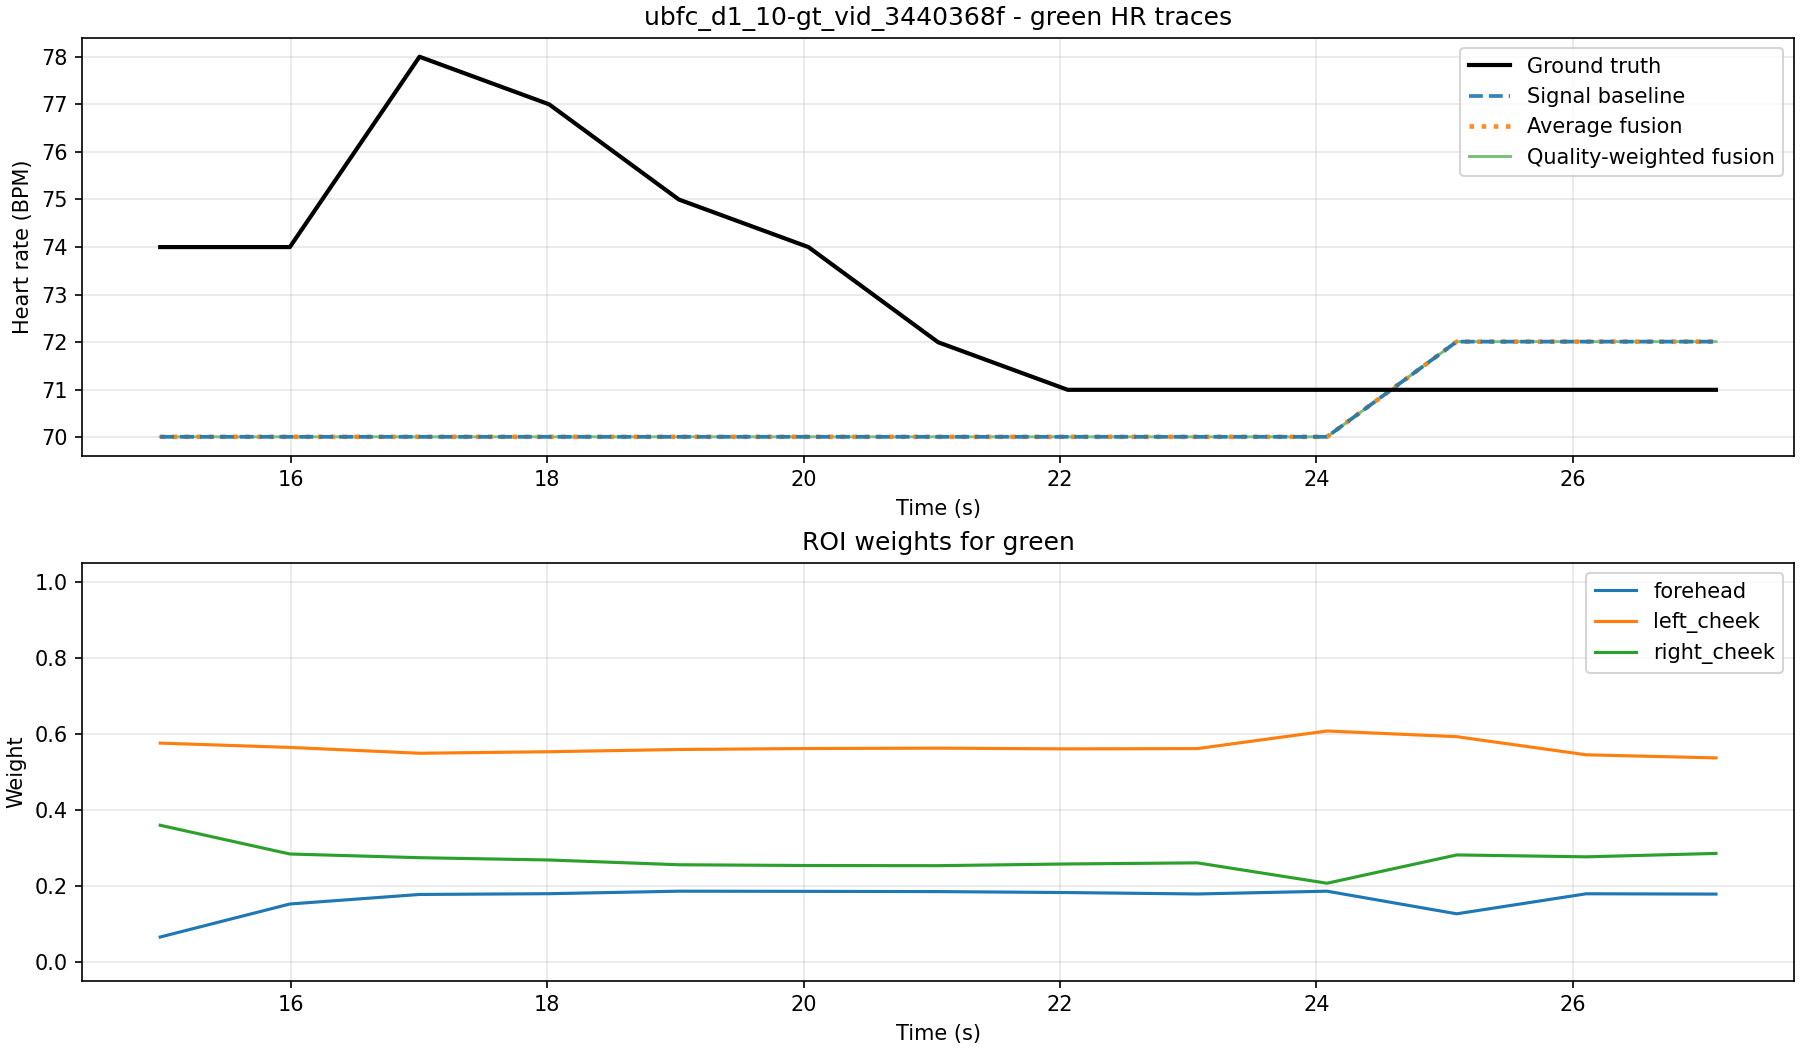

In [4]:
if SHOW_SAMPLE_VISUALIZATION:
    first_processed = next((item for item in manifest.get("items", []) if item.get("status") == "processed"), None)
    if first_processed is not None:
        visualization_path = output_root / first_processed["outputs"]["fusion_visualization_png"]
        if visualization_path.exists():
            display(Image(filename=str(visualization_path)))